In [1]:
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import KFold
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd

def timeit(f):

    def timed(*args, **kw):

        ts = time.time()
        result = f(*args, **kw)
        te = time.time()

        print(f'func: {f.__name__} took: {te-ts:.4f} sec')
        return result

    return timed


# Data Preprocessing:

In [2]:
df = pd.DataFrame(columns=["Sequence"])

In [3]:
df.head()

,Sequence


In [4]:
import os

# import all sequences
def create_rows(directory, extension):
    sequences = []
    for filename in os.listdir(directory):
        if os.path.isfile(os.path.join(directory, filename)): # Check if it's a file
            if filename.lower().endswith(extension):
                file = open(os.path.join(directory, filename), 'r')
                content = file.read()
                sequences.append(content)


    return sequences


cholera_sequences = create_rows("ncbi_dataset_cholera/ncbi_dataset/data", ".fna")
tb_sequences = create_rows("ncbi_dataset_tb/ncbi_dataset/data", ".fna")
anthrax_sequences = create_rows("ncbi_dataset_anthracis/ncbi_dataset/data", ".fna")



In [5]:
print(np.shape(cholera_sequences))

(3,)


In [6]:
def reverse_complement(sequences):
    rev_complements = []
    for sequence in sequences:
        rev_complement = ""
        for nuc in reversed(sequence):
            if nuc == "A":
                rev_complement += "T"
            elif nuc == "T":
                rev_complement += "A"
            elif nuc == "G":
                rev_complement += "C"
            elif nuc == "C":
                rev_complement += "G"
        rev_complements.append(rev_complement)

    return rev_complements
        

In [7]:
cholera_revs = reverse_complement(cholera_sequences)
tb_revs = reverse_complement(tb_sequences)
anthrax_revs = reverse_complement(anthrax_sequences)


In [8]:
# chop up sequences into substrings of length 500 
def split_sequences(sequence_list, chunk_size):
    chunks = []
    for sequence in sequence_list:
        sequence = sequence.replace("\n", "")
        num_extra_chars = len(sequence) % chunk_size
        sequence = sequence[:(-1 * num_extra_chars)] 
        for i in range(0, len(sequence), chunk_size):
            chunks.append([sequence[i:i + chunk_size]])
        

    chunks = np.array(chunks).flatten()
    return chunks

cholera_sequences_split = split_sequences(cholera_sequences, 500)
cholera_sequences_split_rev = split_sequences(cholera_revs, 500)
cholera_sequences_split = np.concatenate((cholera_sequences_split, cholera_sequences_split_rev), axis = 0)

tb_sequences_split = split_sequences(tb_sequences, 500)
tb_sequences_split_rev = split_sequences(tb_revs, 500)
tb_sequences_split = np.concatenate((tb_sequences_split, tb_sequences_split_rev), axis = 0)

anthrax_sequences_split = split_sequences(anthrax_sequences, 500)
anthrax_sequences_split_rev = split_sequences(anthrax_revs, 500)
anthrax_sequences_split = np.concatenate((anthrax_sequences_split, anthrax_sequences_split_rev), axis = 0)

In [9]:
df["Sequence"] = cholera_sequences_split
df["Label"] = ["Cholera"] * len(cholera_sequences_split)

tb_df = pd.DataFrame({"Sequence": tb_sequences_split, "Label": ["Tuberculosis"] * len(tb_sequences_split)})
anthrax_df = pd.DataFrame({"Sequence": anthrax_sequences_split, "Label": ["Anthrax"] * len(anthrax_sequences_split)})

In [10]:
df = pd.concat([df, tb_df, anthrax_df], ignore_index=True)

In [12]:
from sklearn.preprocessing import OneHotEncoder


In [13]:
def one_hot_encode_dna(sequence):

    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_sequence = encoder.fit_transform(np.array(list(sequence)).reshape(-1, 1))
    return encoded_sequence

numerical_seqs = []

for sequence in df["Sequence"]:
    numerical_seqs.append([one_hot_encode_dna(sequence)])

In [ ]:

num_rows = np.shape(numerical_seqs)[0]

numerical_seqs = np.array(numerical_seqs).reshape(num_rows, 500, 4)
df["Encoded Sequence"] = list(numerical_seqs)

In [15]:
df_encoded = pd.get_dummies(df["Label"], dtype = "int")
df_encoded.head()
concatenated_labels = np.concatenate([df_encoded['Anthrax'].to_numpy().reshape(-1, 1), 
                            df_encoded['Cholera'].to_numpy().reshape(-1, 1),
                            df_encoded['Tuberculosis'].to_numpy().reshape(-1, 1)], axis=1)


df["Encoded Label"] = list(concatenated_labels)




In [ ]:
transposed = np.zeros((83834*2, 4, 500))
for i in range(len(df)):
    transposed[i] = df.loc[i, 'Encoded Sequence'].T


df["Encoded Sequence Transposed"] = list(transposed)

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df["Encoded Sequence Transposed"], df["Encoded Label"], train_size=0.8)



In [ ]:

X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [22]:
X_train = np.array(X_train.tolist(), dtype=float)
X_test = np.array(X_test.tolist(), dtype=float)
y_train = np.array(y_train.tolist(), dtype=float)
y_test = np.array(y_test.tolist(), dtype=float)

In [23]:
X_train = torch.tensor(X_train, dtype=torch.float)
X_test = torch.tensor(X_test, dtype=torch.float)
y_train = torch.tensor(y_train, dtype=torch.float)
y_test = torch.tensor(y_test, dtype=torch.float)

In [25]:
import pickle

with open('X_train.pkl', 'wb') as file:
    pickle.dump(X_train, file)
    
with open('X_test.pkl', 'wb') as file:
    pickle.dump(X_test, file)
    
with open('y_train.pkl', 'wb') as file:
    pickle.dump(y_train, file)
    
with open('y_test.pkl', 'wb') as file:
    pickle.dump(y_test, file)

# After this step, the dataset should have been formed/saved as a pkl file

In [18]:
class DNA_Dataset():
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Models

In [19]:
class Trainer:
    def __init__(self, model, opt_method, learning_rate, batch_size, epoch, l2):
        self.model = model
        if opt_method == "sgdm":
            self.optimizer = torch.optim.SGD(model.parameters(), learning_rate, momentum=0.9, weight_decay=l2)
        elif opt_method == "adam":
            self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=l2)
        else:
            raise NotImplementedError("This optimization is not supported")

        self.epoch = epoch
        self.batch_size = batch_size

    @timeit
    def train(self, train_data, val_data, early_stop=True, verbose=True, draw_curve=True):
        train_loader = DataLoader(train_data, batch_size=self.batch_size, shuffle=True)

        train_loss_list, train_acc_list = [], []
        val_loss_list, val_acc_list = [], []

        weights = self.model.state_dict()
        lowest_val_loss = np.inf
        loss_func = nn.CrossEntropyLoss()

        for n in tqdm(range(self.epoch), leave=False):
            self.model.train()
            for X_batch, y_batch in train_loader:
                
                if y_batch.ndim > 1: #this is new
                    y_batch = torch.argmax(y_batch, dim=1) # this is new
                    
                y_pred = self.model(X_batch)
                batch_loss = loss_func(y_pred, y_batch)

                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()

            train_loss, train_acc = self.evaluate(train_data)
            val_loss, val_acc = self.evaluate(val_data)

            train_loss_list.append(train_loss)
            train_acc_list.append(train_acc)
            val_loss_list.append(val_loss)
            val_acc_list.append(val_acc)

            if verbose:
                print(f"Epoch {n+1}/{self.epoch} | "
                      f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                      f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

            if early_stop and val_loss < lowest_val_loss:
                lowest_val_loss = val_loss
                weights = self.model.state_dict()

        if draw_curve:
            x_axis = np.arange(self.epoch)
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            axes[0].plot(x_axis, train_loss_list, label="Train")
            axes[0].plot(x_axis, val_loss_list, label="Validation")
            axes[0].set_title("Loss")
            axes[0].legend()

            axes[1].plot(x_axis, train_acc_list, label="Train")
            axes[1].plot(x_axis, val_acc_list, label="Validation")
            axes[1].set_title("Accuracy")
            axes[1].legend()
            plt.tight_layout()
            plt.show()

        if early_stop:
            self.model.load_state_dict(weights)

        return {
            "train_loss_list": train_loss_list,
            "train_acc_list": train_acc_list,
            "val_loss_list": val_loss_list,
            "val_acc_list": val_acc_list,
        }

    def evaluate(self, data, print_acc=False):
        self.model.eval()
        loader = DataLoader(data, batch_size=self.batch_size, shuffle=False)
        loss_func = nn.CrossEntropyLoss()
        acc, loss = 0.0, 0.0
        for X_batch, y_batch in loader:
            
            if y_batch.ndim > 1: #this is new
                    y_batch = torch.argmax(y_batch, dim=1) # this is new
            
            with torch.no_grad():
                batch_importance = y_batch.shape[0] / len(data)
                y_pred = self.model(X_batch)
                batch_loss = loss_func(y_pred, y_batch)
                batch_acc = torch.sum(torch.argmax(y_pred, axis=-1) == y_batch) / y_batch.shape[0]
                acc += batch_acc.detach().cpu().item() * batch_importance
                loss += batch_loss.detach().cpu().item() * batch_importance

        if print_acc:
            print(f"Accuracy: {acc:.3f}")
        return loss, acc


In [20]:
def KFoldCrossValidation(
    model_class, k, 
    X_train, y_train, X_test, y_test, 
    opt_method='adam', learning_rate=2e-3, batch_size=128, epoch=30, l2=0.0,
    early_break=False,
    **model_args
):
    test_data = DNA_Dataset(X_test, y_test)
    kf = KFold(n_splits=k, shuffle=True)
    train_acc_list, test_acc_list = [], []
    for i, (train_index, val_index) in enumerate(kf.split(X_train)):
        print(f"Fold {i}:")
        
        train_data = DNA_Dataset(X_train[train_index], y_train[train_index])
        val_data = DNA_Dataset(X_train[val_index], y_train[val_index])
        
        model = model_class(**model_args)

        trainer = Trainer(model, opt_method, learning_rate, batch_size, epoch, l2)

        if str(model_class) == "DeepCNN" or str(model_class) == "DeepCNNDropout": 
            trainer = Trainer(model, opt_method, learning_rate, batch_size, epoch, l2)
        
        elif str(model_class) == "LSTM" or str(model_class) == "LSTMDeep":
            trainer = LSTMTrainer(model, opt_method, learning_rate, batch_size, epoch, l2)
        
        res = trainer.train(train_data, val_data)
        train_acc_best = res['train_acc_list'][np.argmin(res['val_loss_list'])]
        test_loss, test_acc = trainer.evaluate(test_data)
        
        train_acc_list.append(train_acc_best)
        test_acc_list.append(test_acc)
        
        print(f"Training accuracy: {train_acc_best}")
        print(f"Test accuracy: {test_acc}")
        
        if early_break:
            break
    
    if not early_break:
        print("Final results:")
        print(f"Training accuracy: {np.mean(train_acc_list)}+/-{np.std(train_acc_list)}")
        print(f"Test accuracy: {np.mean(test_acc_list)}+/-{np.std(test_acc_list)}")


# Convolutional Neural Network

In [22]:
# This CNN has 2 layers but no dropout

class DeepCNN(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=16, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(4000, 64)
        self.fc2 = nn.Linear(64, 3)
        self.activation = nn.ReLU()
        self.softmax = nn.Softmax()
        self.pool = nn.AvgPool1d(kernel_size=2)

    def forward(self, x): 
        x = self.pool(self.activation(self.conv1(x)))
        x = self.pool(self.activation(self.conv2(x)))
        x = torch.flatten(x, start_dim=1)
        x = self.activation(self.fc1(x))
        x = nn.Softmax(dim=-1)(self.fc2(x))
        return x

In [23]:
# This CNN has 2 layers and dropout

class DeepCNNDropout(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=16, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.dropout = nn.Dropout(p=0.15)
        self.fc1 = nn.Linear(4000, 64)
        self.fc2 = nn.Linear(64, 3)
        self.activation = nn.ReLU()
        self.softmax = nn.Softmax()
        self.pool = nn.AvgPool1d(kernel_size=2)

    def forward(self, x): 
        x = self.pool(self.activation(self.conv1(x)))
        x = self.dropout(x)
        x = self.pool(self.activation(self.conv2(x)))
        x = torch.flatten(x, start_dim=1)
        x = self.activation(self.fc1(x))
        x = nn.Softmax(dim=-1)(self.fc2(x))
        return x

In [24]:
# import all data
def load_dataset(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)

    return data

In [25]:
X_train = load_dataset('X_train.pkl')
X_test = load_dataset('X_test.pkl')
y_train = load_dataset('y_train.pkl')
y_test = load_dataset('y_test.pkl')

# Training and Visualization of DeepCNN (no dropout)

Fold 0:


  3%|▎         | 1/30 [00:59<28:43, 59.45s/it]

Epoch 1/30 | Train Loss: 0.5918, Train Acc: 0.9593 | Val Loss: 0.5952, Val Acc: 0.9556


  7%|▋         | 2/30 [02:00<28:07, 60.27s/it]

Epoch 2/30 | Train Loss: 0.5897, Train Acc: 0.9612 | Val Loss: 0.5935, Val Acc: 0.9573


...

 93%|█████████▎| 28/30 [49:46<02:50, 85.43s/it]

Epoch 28/30 | Train Loss: 0.5692, Train Acc: 0.9821 | Val Loss: 0.5749, Val Acc: 0.9764


 97%|█████████▋| 29/30 [51:13<01:26, 86.03s/it]

Epoch 29/30 | Train Loss: 0.5660, Train Acc: 0.9854 | Val Loss: 0.5716, Val Acc: 0.9795


Epoch 30/30 | Train Loss: 0.5728, Train Acc: 0.9782 | Val Loss: 0.5768, Val Acc: 0.9744


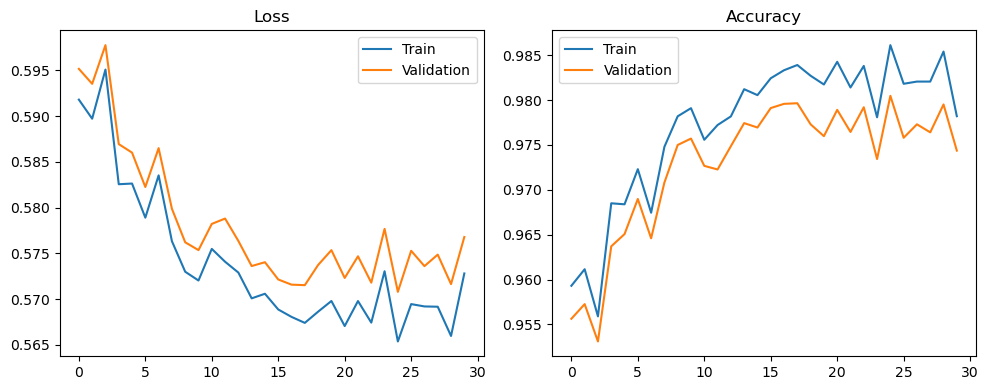

func: train took: 3164.8208 sec
Training accuracy: 0.9861219834045277
Test accuracy: 0.9742649251541486
Fold 1:


  3%|▎         | 1/30 [00:32<15:32, 32.15s/it]

Epoch 1/30 | Train Loss: 0.6197, Train Acc: 0.9304 | Val Loss: 0.6197, Val Acc: 0.9304


  7%|▋         | 2/30 [01:08<16:15, 34.83s/it]

Epoch 2/30 | Train Loss: 0.5977, Train Acc: 0.9530 | Val Loss: 0.5984, Val Acc: 0.9522


...

 93%|█████████▎| 28/30 [44:20<03:01, 90.95s/it]

Epoch 28/30 | Train Loss: 0.5692, Train Acc: 0.9819 | Val Loss: 0.5726, Val Acc: 0.9784


 97%|█████████▋| 29/30 [45:53<01:31, 91.30s/it]

Epoch 29/30 | Train Loss: 0.5667, Train Acc: 0.9846 | Val Loss: 0.5708, Val Acc: 0.9804


Epoch 30/30 | Train Loss: 0.5669, Train Acc: 0.9844 | Val Loss: 0.5709, Val Acc: 0.9803


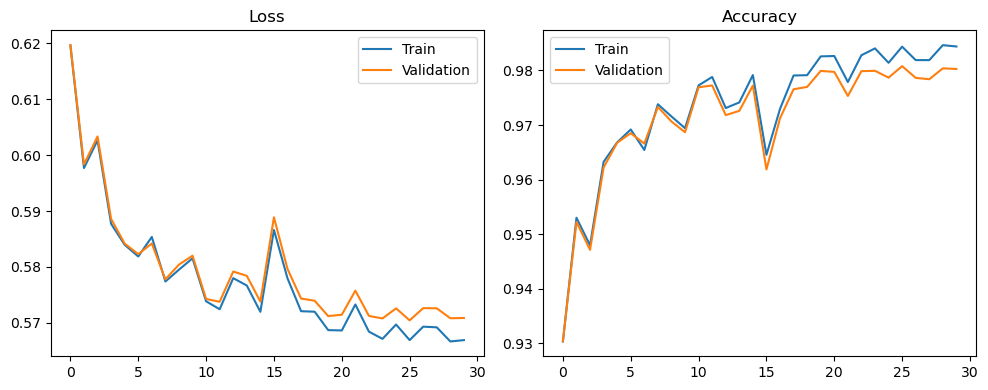

func: train took: 2848.0182 sec
Training accuracy: 0.9843552553593612
Test accuracy: 0.9789467405112576
Fold 2:


  3%|▎         | 1/30 [00:34<16:37, 34.39s/it]

Epoch 1/30 | Train Loss: 0.6206, Train Acc: 0.9296 | Val Loss: 0.6194, Val Acc: 0.9307


  7%|▋         | 2/30 [01:08<16:04, 34.45s/it]

Epoch 2/30 | Train Loss: 0.5909, Train Acc: 0.9601 | Val Loss: 0.5894, Val Acc: 0.9612


...

 93%|█████████▎| 28/30 [43:49<03:05, 92.82s/it]

Epoch 28/30 | Train Loss: 0.5664, Train Acc: 0.9850 | Val Loss: 0.5706, Val Acc: 0.9806


 97%|█████████▋| 29/30 [45:20<01:32, 92.23s/it]

Epoch 29/30 | Train Loss: 0.5664, Train Acc: 0.9849 | Val Loss: 0.5706, Val Acc: 0.9806


Epoch 30/30 | Train Loss: 0.5662, Train Acc: 0.9852 | Val Loss: 0.5714, Val Acc: 0.9798


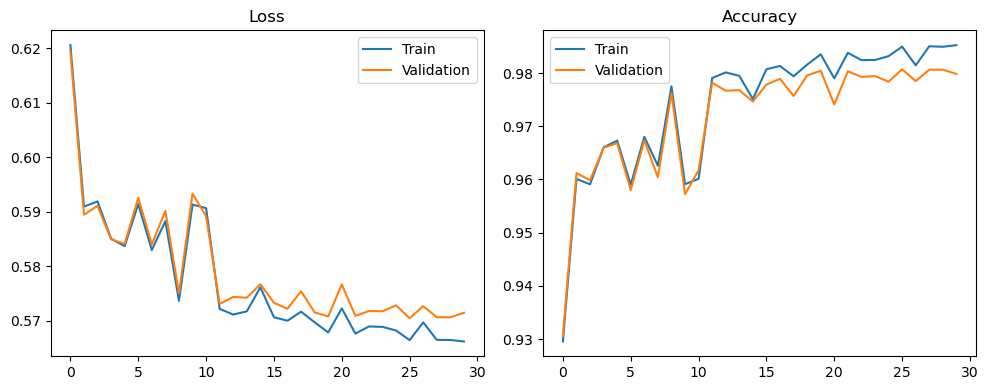

func: train took: 2811.5414 sec
Training accuracy: 0.9849591268465622
Test accuracy: 0.9796326116812556
Final results:
Training accuracy: 0.9851454552034836+/-0.0007331987856142404
Test accuracy: 0.977614759115554+/-0.0023851828011282354


In [10]:
KFoldCrossValidation(DeepCNN, 3, X_train, y_train, X_test, y_test, l2=1e-5)

# Training and Visualization for CNN with Dropout

Fold 0:


  3%|▎         | 1/30 [00:33<16:22, 33.88s/it]

Epoch 1/30 | Train Loss: 0.5920, Train Acc: 0.9589 | Val Loss: 0.5918, Val Acc: 0.9593


  7%|▋         | 2/30 [01:11<16:47, 35.97s/it]

Epoch 2/30 | Train Loss: 0.6045, Train Acc: 0.9463 | Val Loss: 0.6047, Val Acc: 0.9459


...

 93%|█████████▎| 28/30 [43:52<03:28, 104.31s/it]

Epoch 28/30 | Train Loss: 0.5818, Train Acc: 0.9693 | Val Loss: 0.5840, Val Acc: 0.9671


 97%|█████████▋| 29/30 [45:26<01:41, 101.31s/it]

Epoch 29/30 | Train Loss: 0.5681, Train Acc: 0.9832 | Val Loss: 0.5710, Val Acc: 0.9803


Epoch 30/30 | Train Loss: 0.5688, Train Acc: 0.9826 | Val Loss: 0.5718, Val Acc: 0.9794


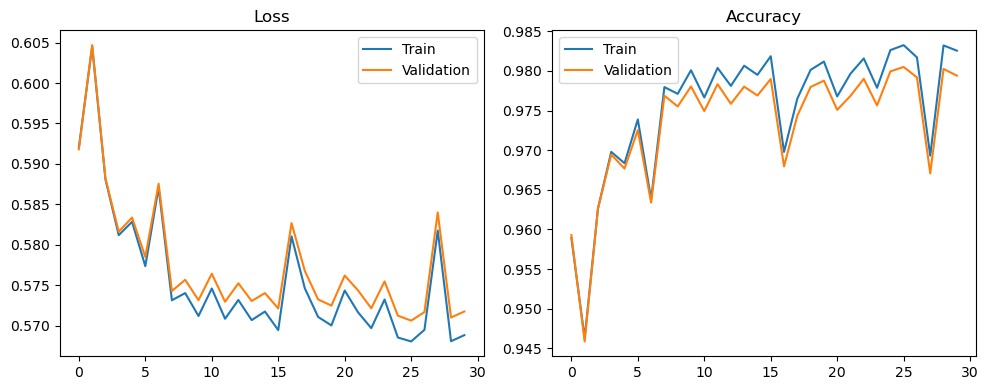

func: train took: 2823.3891 sec
Training accuracy: 0.9832479702981322
Test accuracy: 0.9778732033195926
Fold 1:


  3%|▎         | 1/30 [00:32<15:31, 32.13s/it]

Epoch 1/30 | Train Loss: 0.5939, Train Acc: 0.9572 | Val Loss: 0.5949, Val Acc: 0.9560


  7%|▋         | 2/30 [01:04<15:03, 32.28s/it]

Epoch 2/30 | Train Loss: 0.6139, Train Acc: 0.9359 | Val Loss: 0.6139, Val Acc: 0.9356


...

 93%|█████████▎| 28/30 [38:57<02:54, 87.39s/it]

Epoch 28/30 | Train Loss: 0.5722, Train Acc: 0.9789 | Val Loss: 0.5756, Val Acc: 0.9754


 97%|█████████▋| 29/30 [40:28<01:28, 88.70s/it]

Epoch 29/30 | Train Loss: 0.5685, Train Acc: 0.9828 | Val Loss: 0.5721, Val Acc: 0.9791


Epoch 30/30 | Train Loss: 0.5734, Train Acc: 0.9778 | Val Loss: 0.5759, Val Acc: 0.9752


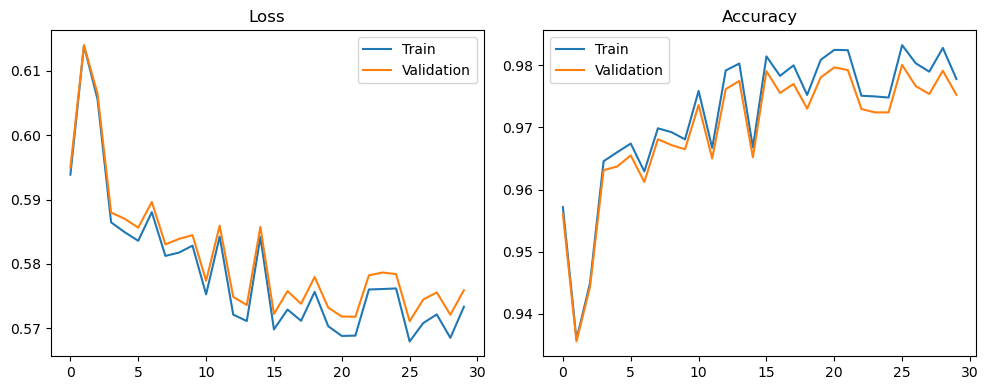

func: train took: 2522.3687 sec
Training accuracy: 0.9832034264115517
Test accuracy: 0.9745034889997976
Fold 2:


  3%|▎         | 1/30 [00:36<17:40, 36.56s/it]

Epoch 1/30 | Train Loss: 0.5954, Train Acc: 0.9556 | Val Loss: 0.5965, Val Acc: 0.9545


  7%|▋         | 2/30 [01:09<16:03, 34.39s/it]

Epoch 2/30 | Train Loss: 0.5914, Train Acc: 0.9596 | Val Loss: 0.5920, Val Acc: 0.9590


...

 93%|█████████▎| 28/30 [46:52<04:09, 124.94s/it]

Epoch 28/30 | Train Loss: 0.5682, Train Acc: 0.9831 | Val Loss: 0.5711, Val Acc: 0.9802


 97%|█████████▋| 29/30 [48:58<02:05, 125.17s/it]

Epoch 29/30 | Train Loss: 0.5723, Train Acc: 0.9788 | Val Loss: 0.5748, Val Acc: 0.9761


Epoch 30/30 | Train Loss: 0.5686, Train Acc: 0.9827 | Val Loss: 0.5717, Val Acc: 0.9793


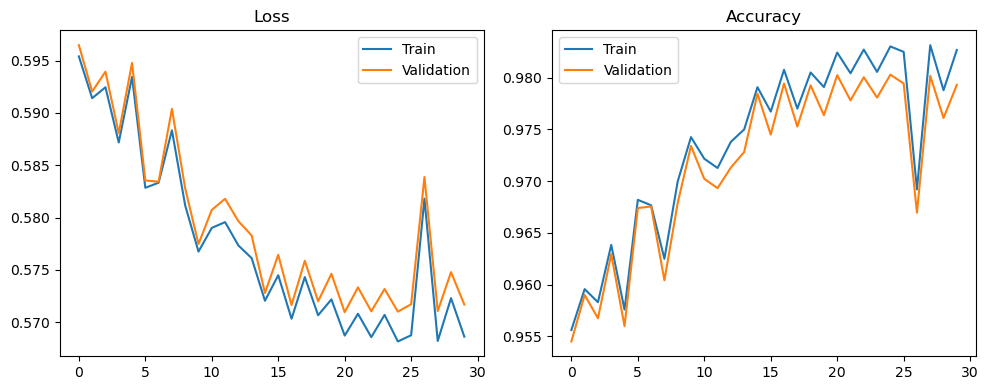

func: train took: 3067.9387 sec
Training accuracy: 0.9824094472339356
Test accuracy: 0.9788870995498455
Final results:
Training accuracy: 0.9829536146478732+/-0.0003852139407753456
Test accuracy: 0.9770879306230785+/-0.0018737663087199227


In [11]:
KFoldCrossValidation(DeepCNNDropout, 3, X_train, y_train, X_test, y_test, l2=1e-5)

# LSTM Model Architecture

In [12]:
class LSTM(nn.Module):
    def __init__(self, input_size=500, hidden_size=128, num_layers=2, num_classes=3):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                            batch_first=True)
        
        lstm_output_size = hidden_size
        
        self.fc1 = nn.Linear(lstm_output_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        # x: [batch_size, seq_len, input_size]
        lstm_out, _ = self.lstm(x)  # lstm_out: [batch, seq_len, hidden]
        final_output = lstm_out[:, -1, :]  # take last time step
        out = self.relu(self.fc1(final_output))
        out = self.fc2(out)
        return out

# LSTM (4 Layers) Architecture

In [ ]:
class LSTMDeep(nn.Module):
    def __init__(self, input_size=500, hidden_size=128, num_layers=4, num_classes=3):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                            batch_first=True)
        
        lstm_output_size = hidden_size
        
        self.fc1 = nn.Linear(lstm_output_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        # x: [batch_size, seq_len, input_size]
        lstm_out, _ = self.lstm(x)  # lstm_out: [batch, seq_len, hidden]
        final_output = lstm_out[:, -1, :]  # take last time step
        out = self.relu(self.fc1(final_output))
        out = self.fc2(out)
        return out

# LSTM (Bidirectional) Architecture

In [35]:
class LSTM_Bid(nn.Module):
    def __init__(self, input_size=500, hidden_size=64, num_layers=2, num_classes=3):
        super(LSTM_Bid, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                            batch_first=True, bidirectional=True)
        
        lstm_output_size = hidden_size * 2
        
        self.fc1 = nn.Linear(lstm_output_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # lstm_out: [batch, seq_len, hidden]
        final_output = lstm_out[:, -1, :]  # take last time step
        out = self.relu(self.fc1(final_output))
        out = self.fc2(out)
        return out

In [14]:
class LSTMTrainer:
    def __init__(self, model, opt_method, learning_rate=0.001, epoch=10, batch_size=128, l2 = 1e-5, draw_curve=True):
        self.model = model
        if opt_method == "sgdm":
            self.optimizer = torch.optim.SGD(model.parameters(), learning_rate, momentum=0.9, weight_decay=l2)
        elif opt_method == "adam":
            self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=l2)
        else:
            raise NotImplementedError("This optimization is not supported")

        self.epoch = epoch
        self.batch_size = batch_size

        # For plotting
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []

    def train(self, train_data, val_data, early_stop=True, verbose=True, draw_curve=True):
        
        train_loader = DataLoader(train_data, batch_size=self.batch_size, shuffle=True)
        
        for n in tqdm(range(self.epoch), leave=False):
            self.model.train()

            total_loss = 0
            correct = 0
            total = 0
            
            for X_batch, y_batch in train_loader:
                
                if y_batch.ndim > 1: #this is new
                    y_batch = torch.argmax(y_batch, dim=1) # this is new
                    

                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            epoch_loss = total_loss / len(self.train_loader)
            epoch_acc = 100 * correct / total

            self.train_losses.append(epoch_loss)
            self.train_accuracies.append(epoch_acc)

            print(f"Epoch [{epoch+1}/{self.epoch}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

            if self.val_loader:
                self.evaluate()

        if self.draw_curve:
            self.plot()

    def evaluate(self):
        self.model.eval()
        correct = 0
        total = 0
        val_loss = 0

        with torch.no_grad():
            for inputs, labels in self.val_loader:
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(self.val_loader)
        epoch_val_acc = 100 * correct / total

        self.val_losses.append(epoch_val_loss)
        self.val_accuracies.append(epoch_val_acc)

        print(f"Validation - Loss: {epoch_val_loss:.4f}, Accuracy: {epoch_val_acc:.2f}%")

    def plot(self):
        epochs = range(1, self.epoch + 1)

        plt.figure(figsize=(12, 5))

        # Loss plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.train_losses, label='Train Loss')
        if self.val_losses:
            plt.plot(epochs, self.val_losses, label='Validation Loss')
        plt.title("Loss Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        # Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.train_accuracies, label='Train Accuracy')
        if self.val_accuracies:
            plt.plot(epochs, self.val_accuracies, label='Validation Accuracy')
        plt.title("Accuracy Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy (%)")
        plt.legend()

        plt.tight_layout()
        plt.show()


# Training and Visualization for Unidirectional LSTM

Fold 0:


  3%|▎         | 1/30 [00:17<08:33, 17.70s/it]

Epoch 1/30 | Train Loss: 0.1454, Train Acc: 0.9535 | Val Loss: 0.1539, Val Acc: 0.9500


  7%|▋         | 2/30 [00:34<08:02, 17.24s/it]

Epoch 2/30 | Train Loss: 0.0997, Train Acc: 0.9691 | Val Loss: 0.1205, Val Acc: 0.9609


...

 93%|█████████▎| 28/30 [08:05<00:34, 17.33s/it]

Epoch 28/30 | Train Loss: 0.0137, Train Acc: 0.9949 | Val Loss: 0.2445, Val Acc: 0.9549


 97%|█████████▋| 29/30 [08:22<00:17, 17.22s/it]

Epoch 29/30 | Train Loss: 0.0051, Train Acc: 0.9984 | Val Loss: 0.2412, Val Acc: 0.9578


Epoch 30/30 | Train Loss: 0.0061, Train Acc: 0.9981 | Val Loss: 0.2335, Val Acc: 0.9571


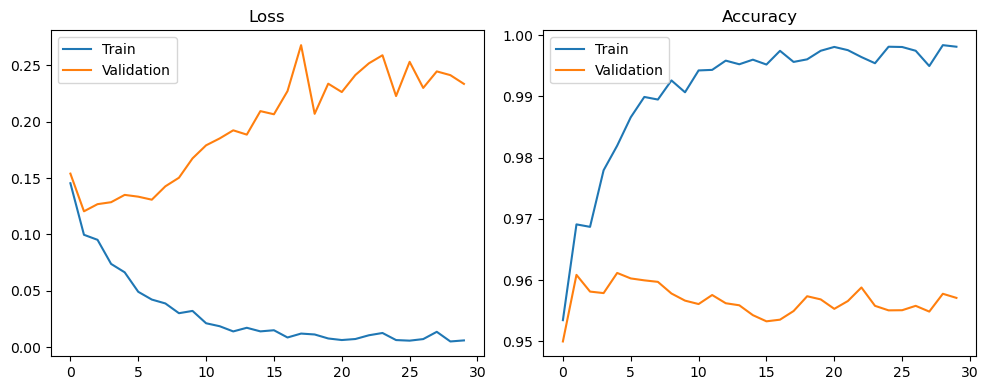

func: train took: 519.5100 sec
Training accuracy: 0.9691015633749984
Test accuracy: 0.9556569450868653
Fold 1:


  3%|▎         | 1/30 [00:17<08:21, 17.30s/it]

Epoch 1/30 | Train Loss: 0.1201, Train Acc: 0.9615 | Val Loss: 0.1370, Val Acc: 0.9552


  7%|▋         | 2/30 [00:34<08:00, 17.16s/it]

Epoch 2/30 | Train Loss: 0.1058, Train Acc: 0.9660 | Val Loss: 0.1323, Val Acc: 0.9561


...

 93%|█████████▎| 28/30 [08:09<00:35, 17.93s/it]

Epoch 28/30 | Train Loss: 0.0075, Train Acc: 0.9974 | Val Loss: 0.2658, Val Acc: 0.9545


 97%|█████████▋| 29/30 [08:27<00:17, 18.00s/it]

Epoch 29/30 | Train Loss: 0.0074, Train Acc: 0.9977 | Val Loss: 0.2371, Val Acc: 0.9550


Epoch 30/30 | Train Loss: 0.0093, Train Acc: 0.9966 | Val Loss: 0.2448, Val Acc: 0.9535


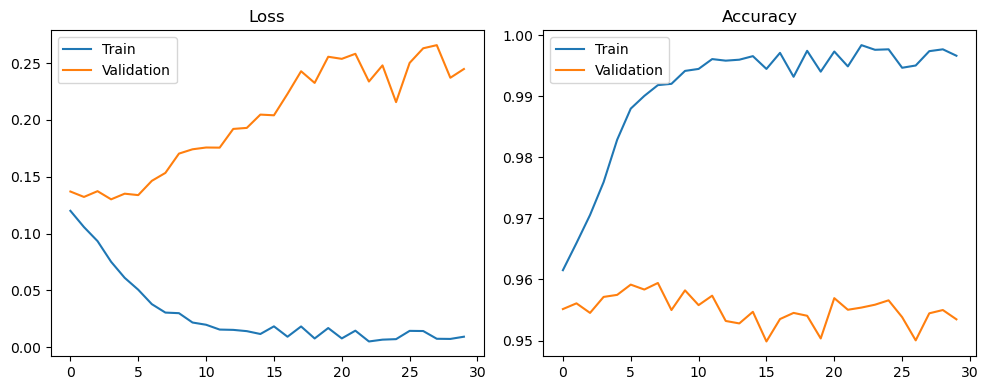

func: train took: 525.2283 sec
Training accuracy: 0.9759346029451706
Test accuracy: 0.953629152395293
Fold 2:


  3%|▎         | 1/30 [00:17<08:19, 17.21s/it]

Epoch 1/30 | Train Loss: 0.1230, Train Acc: 0.9638 | Val Loss: 0.1380, Val Acc: 0.9558


  7%|▋         | 2/30 [00:34<07:59, 17.14s/it]

Epoch 2/30 | Train Loss: 0.0925, Train Acc: 0.9717 | Val Loss: 0.1195, Val Acc: 0.9609


...

 93%|█████████▎| 28/30 [08:03<00:34, 17.40s/it]

Epoch 28/30 | Train Loss: 0.0047, Train Acc: 0.9985 | Val Loss: 0.2515, Val Acc: 0.9524


 97%|█████████▋| 29/30 [08:20<00:17, 17.40s/it]

Epoch 29/30 | Train Loss: 0.0085, Train Acc: 0.9970 | Val Loss: 0.2715, Val Acc: 0.9542


Epoch 30/30 | Train Loss: 0.0044, Train Acc: 0.9985 | Val Loss: 0.2722, Val Acc: 0.9540


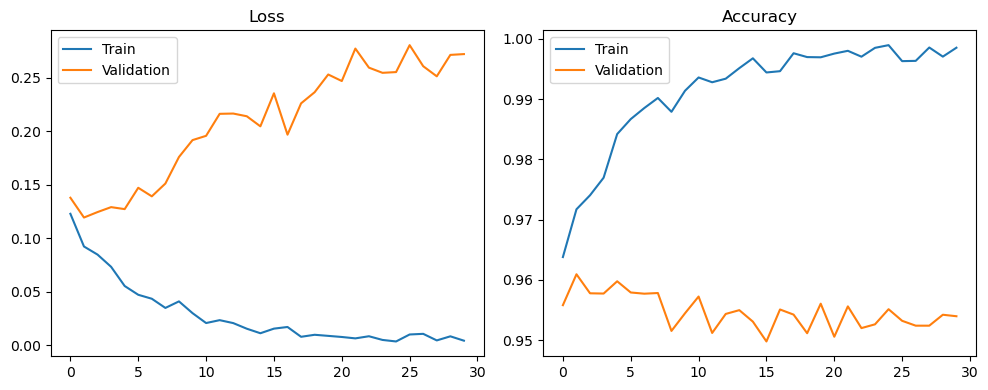

func: train took: 518.3554 sec
Training accuracy: 0.9717186853494123
Test accuracy: 0.9534502296283668
Final results:
Training accuracy: 0.9722516172231939+/-0.0028149150050465173
Test accuracy: 0.954245442370175+/-0.0010007524764059981


In [15]:
KFoldCrossValidation(LSTM, 3, X_train, y_train, X_test, y_test, l2=1e-5)

# Training and Visualization for 4-Layer LSTM

Fold 0:


  3%|▎         | 1/30 [00:27<13:29, 27.91s/it]

Epoch 1/30 | Train Loss: 0.1272, Train Acc: 0.9611 | Val Loss: 0.1399, Val Acc: 0.9559


  7%|▋         | 2/30 [00:58<13:43, 29.42s/it]

Epoch 2/30 | Train Loss: 0.1175, Train Acc: 0.9654 | Val Loss: 0.1380, Val Acc: 0.9577


...

 93%|█████████▎| 28/30 [13:18<00:57, 28.90s/it]

Epoch 28/30 | Train Loss: 0.0140, Train Acc: 0.9955 | Val Loss: 0.2289, Val Acc: 0.9535


 97%|█████████▋| 29/30 [13:48<00:28, 28.95s/it]

Epoch 29/30 | Train Loss: 0.0167, Train Acc: 0.9948 | Val Loss: 0.2355, Val Acc: 0.9529


Epoch 30/30 | Train Loss: 0.0114, Train Acc: 0.9966 | Val Loss: 0.2560, Val Acc: 0.9541


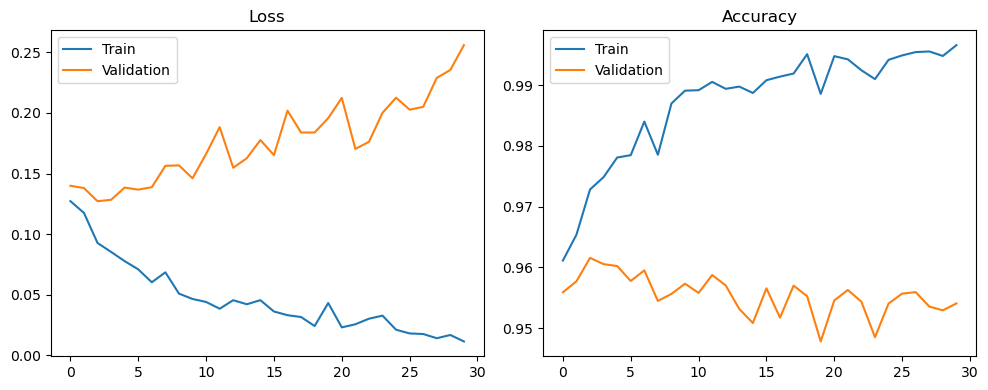

func: train took: 857.4345 sec
Training accuracy: 0.9728142962328594
Test accuracy: 0.9518697441473861
Fold 1:


  3%|▎         | 1/30 [00:29<14:24, 29.82s/it]

Epoch 1/30 | Train Loss: 0.1220, Train Acc: 0.9630 | Val Loss: 0.1337, Val Acc: 0.9595


  7%|▋         | 2/30 [01:02<14:44, 31.57s/it]

Epoch 2/30 | Train Loss: 0.0953, Train Acc: 0.9711 | Val Loss: 0.1192, Val Acc: 0.9635


...

 93%|█████████▎| 28/30 [14:02<01:01, 30.62s/it]

Epoch 28/30 | Train Loss: 0.0217, Train Acc: 0.9942 | Val Loss: 0.2173, Val Acc: 0.9543


 97%|█████████▋| 29/30 [14:32<00:30, 30.44s/it]

Epoch 29/30 | Train Loss: 0.0196, Train Acc: 0.9950 | Val Loss: 0.2359, Val Acc: 0.9563


Epoch 30/30 | Train Loss: 0.0174, Train Acc: 0.9954 | Val Loss: 0.2403, Val Acc: 0.9547


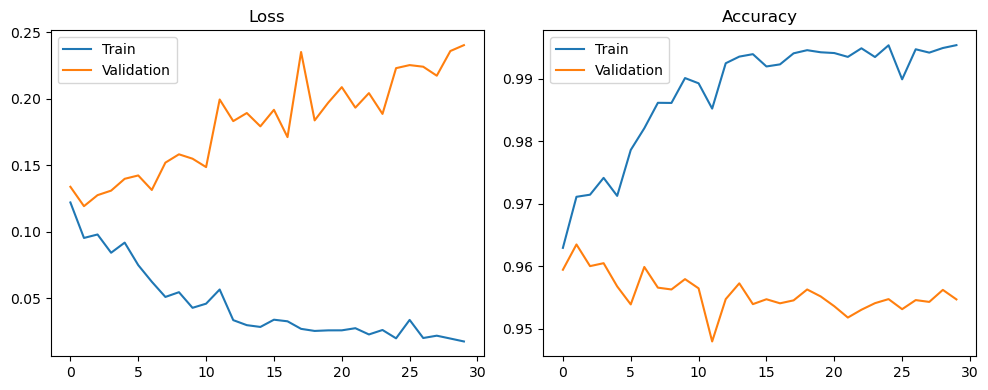

func: train took: 902.7429 sec
Training accuracy: 0.9711483622595039
Test accuracy: 0.9540466392424897
Fold 2:


  3%|▎         | 1/30 [00:29<14:09, 29.31s/it]

Epoch 1/30 | Train Loss: 0.1401, Train Acc: 0.9576 | Val Loss: 0.1481, Val Acc: 0.9545


  7%|▋         | 2/30 [00:58<13:43, 29.42s/it]

Epoch 2/30 | Train Loss: 0.1132, Train Acc: 0.9657 | Val Loss: 0.1252, Val Acc: 0.9597


...

 93%|█████████▎| 28/30 [14:03<01:00, 30.48s/it]

Epoch 28/30 | Train Loss: 0.0188, Train Acc: 0.9933 | Val Loss: 0.2395, Val Acc: 0.9536


 97%|█████████▋| 29/30 [14:34<00:30, 30.51s/it]

Epoch 29/30 | Train Loss: 0.0154, Train Acc: 0.9954 | Val Loss: 0.2005, Val Acc: 0.9550


Epoch 30/30 | Train Loss: 0.0145, Train Acc: 0.9952 | Val Loss: 0.2330, Val Acc: 0.9546


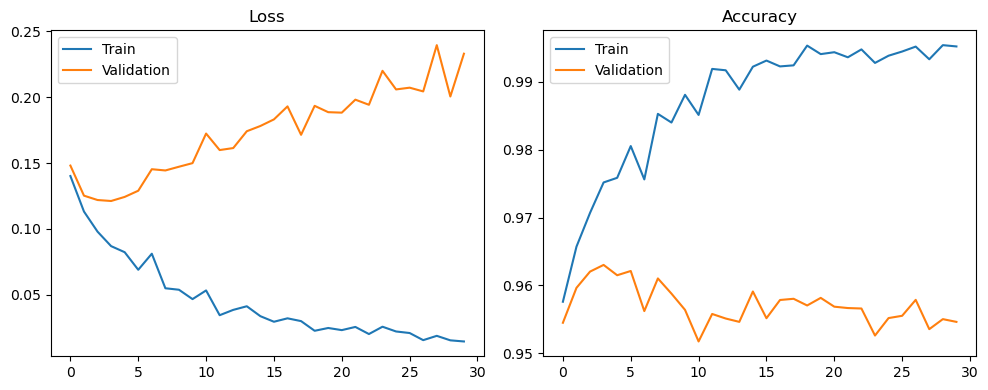

func: train took: 905.4001 sec
Training accuracy: 0.9751741721835095
Test accuracy: 0.9534800499917618
Final results:
Training accuracy: 0.973045610225291+/-0.0016516488747867779
Test accuracy: 0.9531321444605458+/-0.0009221340313857006


In [26]:
KFoldCrossValidation(LSTMDeep, 3, X_train, y_train, X_test, y_test, l2=1e-5)

# Training + Visualization for LSTM, increased L2

Fold 0:


  3%|▎         | 1/30 [00:18<08:44, 18.09s/it]

Epoch 1/30 | Train Loss: 0.1849, Train Acc: 0.9319 | Val Loss: 0.1971, Val Acc: 0.9276


  7%|▋         | 2/30 [00:35<08:22, 17.94s/it]

Epoch 2/30 | Train Loss: 0.1206, Train Acc: 0.9635 | Val Loss: 0.1340, Val Acc: 0.9589


...

 93%|█████████▎| 28/30 [08:20<00:35, 17.99s/it]

Epoch 28/30 | Train Loss: 0.1005, Train Acc: 0.9671 | Val Loss: 0.1453, Val Acc: 0.9532


 97%|█████████▋| 29/30 [08:39<00:18, 18.03s/it]

Epoch 29/30 | Train Loss: 0.1002, Train Acc: 0.9687 | Val Loss: 0.1343, Val Acc: 0.9569


Epoch 30/30 | Train Loss: 0.0895, Train Acc: 0.9732 | Val Loss: 0.1327, Val Acc: 0.9578


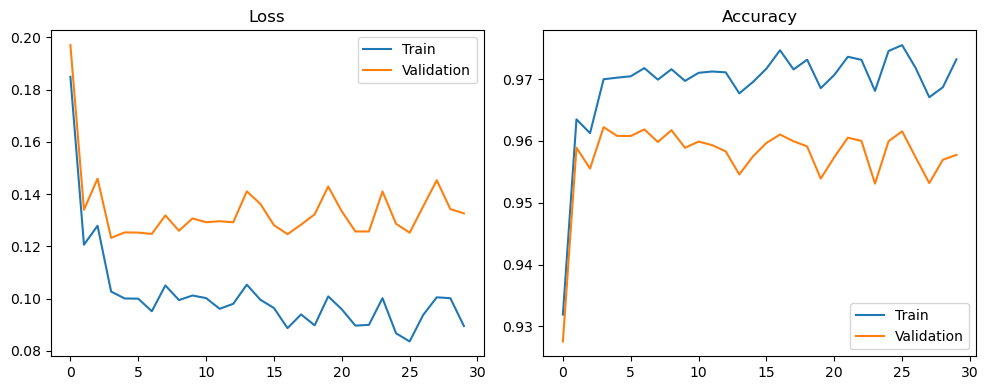

func: train took: 536.8923 sec
Training accuracy: 0.9699738319175902
Test accuracy: 0.9557762270061354
Fold 1:


  3%|▎         | 1/30 [00:17<08:16, 17.12s/it]

Epoch 1/30 | Train Loss: 0.1411, Train Acc: 0.9559 | Val Loss: 0.1465, Val Acc: 0.9533


  7%|▋         | 2/30 [00:34<07:57, 17.04s/it]

Epoch 2/30 | Train Loss: 0.1321, Train Acc: 0.9591 | Val Loss: 0.1383, Val Acc: 0.9565


...

 93%|█████████▎| 28/30 [08:17<00:35, 17.82s/it]

Epoch 28/30 | Train Loss: 0.1085, Train Acc: 0.9656 | Val Loss: 0.1362, Val Acc: 0.9550


 97%|█████████▋| 29/30 [08:34<00:17, 17.59s/it]

Epoch 29/30 | Train Loss: 0.1065, Train Acc: 0.9661 | Val Loss: 0.1337, Val Acc: 0.9569


Epoch 30/30 | Train Loss: 0.0975, Train Acc: 0.9698 | Val Loss: 0.1243, Val Acc: 0.9611


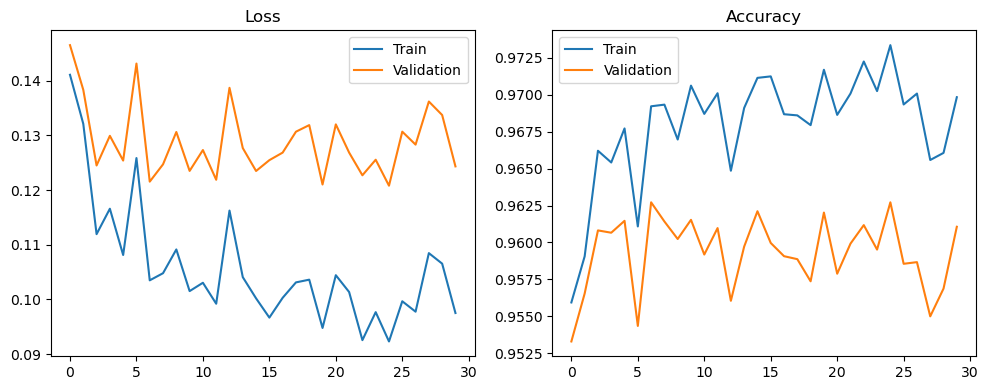

func: train took: 531.8948 sec
Training accuracy: 0.9733513749165875
Test accuracy: 0.9569392258709865
Fold 2:


  3%|▎         | 1/30 [00:16<08:09, 16.89s/it]

Epoch 1/30 | Train Loss: 0.1771, Train Acc: 0.9406 | Val Loss: 0.1858, Val Acc: 0.9361


  7%|▋         | 2/30 [00:33<07:52, 16.88s/it]

Epoch 2/30 | Train Loss: 0.1305, Train Acc: 0.9591 | Val Loss: 0.1424, Val Acc: 0.9538


...

 93%|█████████▎| 28/30 [08:06<00:34, 17.02s/it]

Epoch 28/30 | Train Loss: 0.0935, Train Acc: 0.9716 | Val Loss: 0.1240, Val Acc: 0.9612


 97%|█████████▋| 29/30 [08:23<00:16, 16.99s/it]

Epoch 29/30 | Train Loss: 0.0984, Train Acc: 0.9708 | Val Loss: 0.1335, Val Acc: 0.9586


Epoch 30/30 | Train Loss: 0.0944, Train Acc: 0.9724 | Val Loss: 0.1306, Val Acc: 0.9602


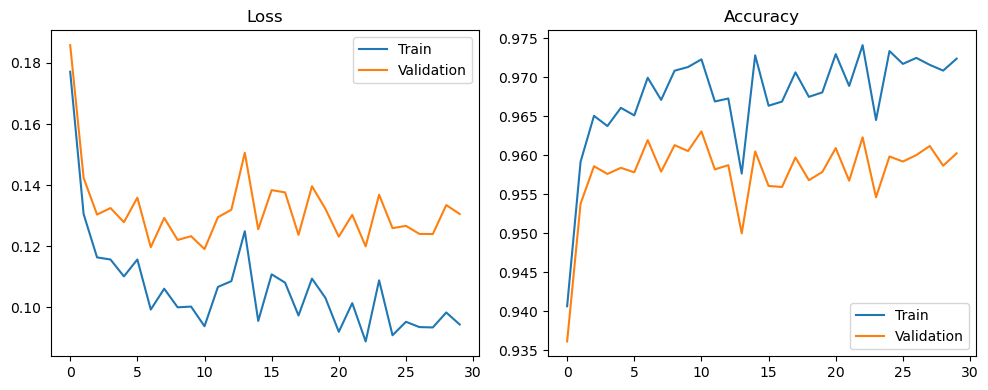

func: train took: 520.5692 sec
Training accuracy: 0.972289008401995
Test accuracy: 0.9594739667238992
Final results:
Training accuracy: 0.9718714050787242+/-0.0014101403190755998
Test accuracy: 0.9573964732003404+/-0.0015438320494217995


In [28]:
KFoldCrossValidation(LSTM, 3, X_train, y_train, X_test, y_test, l2=1e-3)

# Training + Validation for Bidirectional LSTM 
I lost the output because I accidentally converted this code block into a markdown block, so here is a link to a Google doc with screenshots of the output: https://docs.google.com/document/d/1DgC7Ok8ntCFk_9kgVgu-5W8PhJ8I5nMMcEF14aMlXu0/edit?usp=sharing

In [ ]:
KFoldCrossValidation(LSTM_Bid, 3, X_train, y_train, X_test, y_test, l2=1e-3)

# Comments on the Model Outputs: 

A summary of the results can be found in this spreadsheet: https://docs.google.com/spreadsheets/d/1UoMDKfu6zq1dOCCfPEQZlc7PC8_pbVlOIl8nGQlYw40/edit?usp=sharing

The CNN with dropout performed the best overall, while the bidirectional RNN was the best recurrent neural network in terms of testing accuracy. I experimented with different regularization strategies for both the CNNs and the RNNs, and I found that an L2 weight decay of 10^-5 worked best for the CNN, while an L2 weight decay of 10^-3 worked best for the RNN.